In [14]:
# TensorFlow 2.0 부터 TensorFlow 2.15 버전까지는 텐서플로와 동일한 버전의 Keras 2가 설치되고 2.16 이후의 텐서플로 설치 시에는 Keras 3이 설치
# Keras 버전에 따라 패키지 임포트 방법이 다름

# 필요한 경우 packaging 모듈 설치
# !pip install packaging

import tensorflow as tf
from packaging import version

print(tf.__version__)

2.18.0


In [15]:
from tensorflow import keras

print(keras.__version__)

3.8.0


In [16]:
# TensorFlow 버전 정보 가져오기
tf_version = version.parse(tf.__version__)

# 필요한 라이브러리를 불러옵니다.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from keras import optimizers

# TensorFlow 2.15 이하인 경우
if tf_version <= version.parse("2.15.0"):
  from keras.models import Sequential, load_model
  from keras.layers import Dense
  print(f"TensorFlow 버전: {tf.__version__} (2.15 이하) -> tensorflow.keras 임포트")
# TensorFlow 2.15 초과인 경우
else:
  from keras.api.layers import Dense
  from keras.api.models import Sequential, load_model
  print(f"TensorFlow 버전: {tf.__version__} (2.15 초과) -> tensorflow.keras 임포트")

# 실행할 때마다 같은 결과를 출력하기 위해 설정하는 부분입니다.
np.random.seed(3)
tf.random.set_seed(3)

TensorFlow 버전: 2.18.0 (2.15 초과) -> tensorflow.keras 임포트


In [17]:
# data set
x_data = np.array([2, 4, 6, 8, 10, 12, 14])
y_data = np.array([0, 0, 0, 1, 1, 1, 1])

In [18]:
# model: linear regression input dense with dim =1
model = Sequential()
model.add(Dense(1, input_dim = 1, activation='sigmoid'))

# print model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# model compile:  SGD learning_rate of 0.01
sgd = optimizers.SGD(learning_rate = 0.001)
model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy'])

In [20]:
# model fit
#history = model.fit(x_data, y_data, epochs=20, batch_size=1, shuffle=False, verbose=1)
history = model.fit(x_data, y_data, epochs=300, batch_size=1, verbose=1)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7283 - loss: 0.4978  
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7283 - loss: 0.4914 
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7283 - loss: 0.4854 
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7283 - loss: 0.4798 
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7283 - loss: 0.4747 
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7283 - loss: 0.4699 
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7283 - loss: 0.4655 
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7283 - loss: 0.4615 
Epoch 9/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7283 - loss: 0.4579 
Epoch 10/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7283 - loss: 0.4547 
Epoch 11/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7283 - loss: 0.4518 
Epoch 12/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7283 - lo

In [21]:
print(model.layers[0].get_weights())

[array([[0.17183667]], dtype=float32), array([-0.345718], dtype=float32)]


In [22]:
# prediction
print (model.predict(np.array([7])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[[0.7020625]]


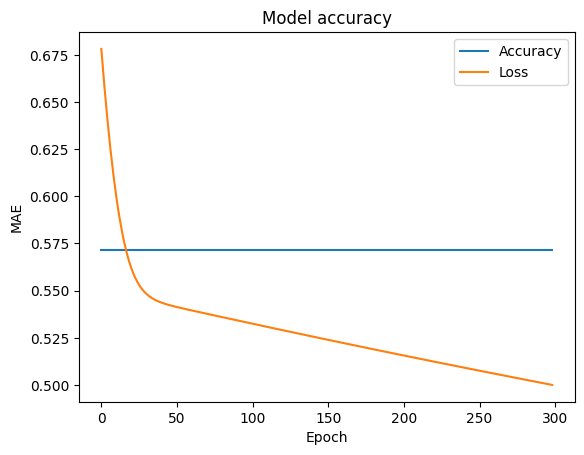

In [23]:
# 학습 정확성 값과 검증 정확성 값을 플롯팅 합니다.
plt.plot(history.history['accuracy'][1:])
plt.plot(history.history['loss'][1:])
plt.title('Model accuracy')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Accuracy', 'Loss'], loc='upper right')
plt.savefig('tran_result.png')